# RNN vs LSTM vs GRU Comparison
This notebook compares the performance of RNN, LSTM, and GRU models on a simple sequential prediction task.

## Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN

## Generate Training Data

In [2]:
X = []
y = []

for i in range(100):
    X.append([i, i+1, i+2])
    y.append(i+3)   

X = np.array(X)
y = np.array(y)

# Reshape for RNN/LSTM/GRU input requirements
X = X.reshape((X.shape[0], X.shape[1], 1))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (100, 3, 1)
y shape: (100,)


## Define Model Builder Function

In [3]:
def build_model(model_type):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(10, activation='relu', input_shape=(3, 1)))
    elif model_type == 'GRU':
        model.add(GRU(10, activation='relu', input_shape=(3, 1)))
    elif model_type == 'RNN':
        model.add(SimpleRNN(10, activation='relu', input_shape=(3, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

## Train Models

In [4]:
models = ["RNN", "LSTM", "GRU"]
history = {}

for m in models:
    print("Training", m)
    model = build_model(m)
    h = model.fit(X, y, epochs=50, verbose=0)
    history[m] = h.history['loss']

print("Training complete!")

Training RNN


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM
Training GRU
Training complete!


## Compare Model Performance

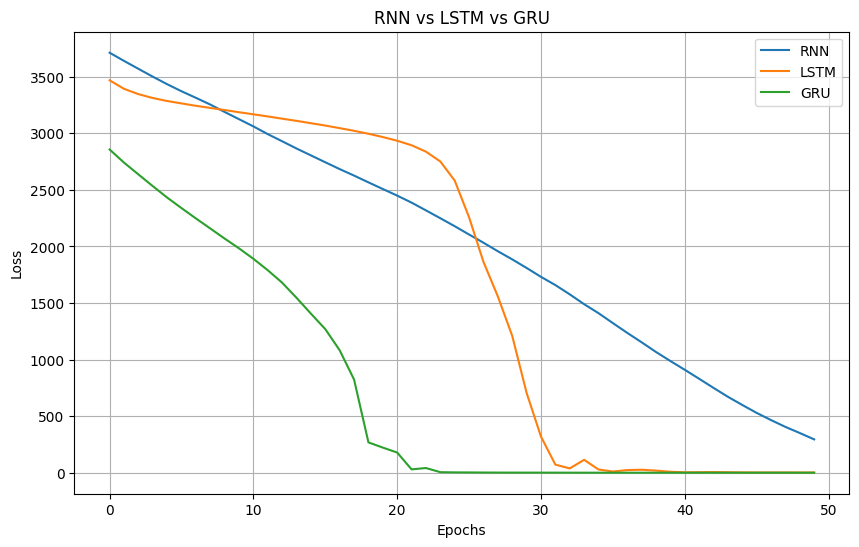

In [ ]:
# Plot results
plt.figure(figsize=(10, 6))
for m in models:
    plt.plot(history[m], label=m)

plt.title("RNN vs LSTM vs GRU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

GRU shows fastest convergence, followed by LSTM, while RNN performs the slowest due to vanishing gradient issues.